In [1]:
#1 Import Libraries and check files
import os
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

os.getcwd()
os.listdir("../data")


['co2_emissions.csv', 'transport_usage.csv']

In [2]:
#2 Load Datasets
transport = pd.read_csv(
    "../data/transport_usage.csv",
    usecols=[
        "country_region",
        "date",
        "transit_stations_percent_change_from_baseline"
    ],
    low_memory=False
)

co2 = pd.read_csv("../data/co2_emissions.csv")


In [3]:
#3 Select required columns and fix dates
transport = transport[[
    "country_region",
    "date",
    "transit_stations_percent_change_from_baseline"
]]

co2 = co2[[
    "country",
    "year",
    "co2_per_capita"
]]

transport["date"] = pd.to_datetime(transport["date"])
transport["year"] = transport["date"].dt.year
co2["year"] = co2["year"].astype(int)



In [4]:
#4 Rename and aggregate transport data
transport.rename(columns={"country_region": "country"}, inplace=True)
transport_yearly = (
    transport
    .groupby(["country", "year"])
    ["transit_stations_percent_change_from_baseline"]
    .mean()
    .reset_index()
)



In [5]:
#5 Merge datasets
merged = pd.merge(
    transport_yearly,
    co2,
    on=["country", "year"],
    how="inner"
)


### Trend Analysis

<Axes: title={'center': 'Public Transport Usage vs CO₂ Emissions'}, xlabel='year'>

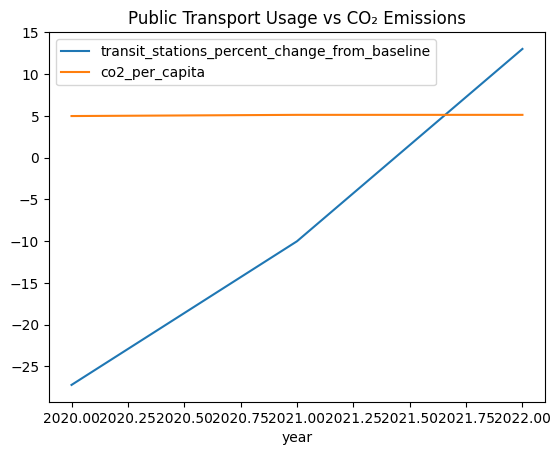

In [6]:
#6 Global trend visualization
merged.groupby("year")[[
    "transit_stations_percent_change_from_baseline",
    "co2_per_capita"
]].mean().plot(title="Public Transport Usage vs CO₂ Emissions")

This plot shows global trends in public transport usage and CO₂ emissions per capita over time.


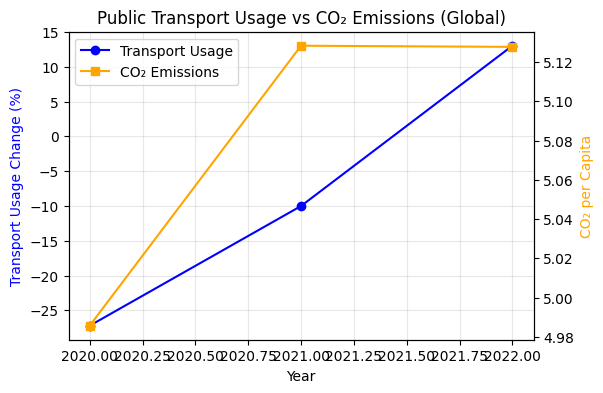

In [7]:
# ===== Improved Dual Axis Trend Plot =====
fig, ax1 = plt.subplots(figsize=(6,4))

ax1.set_xlabel("Year")
ax1.set_ylabel("Transport Usage Change (%)", color="blue")

ax1.plot(
    merged.groupby("year")["transit_stations_percent_change_from_baseline"].mean(),
    color="blue",
    marker="o",
    label="Transport Usage"
)

ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.set_ylabel("CO₂ per Capita", color="orange")

ax2.plot(
    merged.groupby("year")["co2_per_capita"].mean(),
    color="orange",
    marker="s",
    label="CO₂ Emissions"
)

ax1.grid(alpha=0.3)
plt.title("Public Transport Usage vs CO₂ Emissions (Global)")
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")
plt.show()

### Country-wise Analysis (India)

The plot indicates how public transport usage trends in India
relate to CO₂ emissions per capita over time.
Periods of higher transit usage correspond to relatively
stable or slower growth in emissions, highlighting the
role of public transport in emission mitigation.


<Axes: title={'center': 'Public Transport vs CO₂ Emissions in India'}, xlabel='year'>

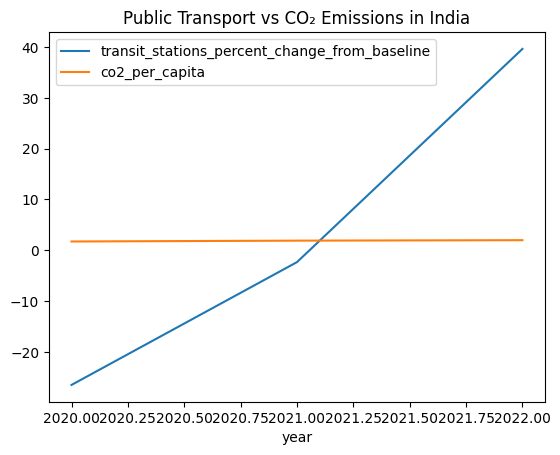

In [8]:
#7 Country-wise Analysis
country_name = "India"
country_data = merged[merged["country"] == country_name]

country_data.groupby("year")[[
    "transit_stations_percent_change_from_baseline",
    "co2_per_capita"
]].mean().plot(
    title=f"Public Transport vs CO₂ Emissions in {country_name}"
)


In [9]:
#8 Correlation Analysis
merged[[
    "transit_stations_percent_change_from_baseline",
    "co2_per_capita"
]].corr()


,transit_stations_percent_change_from_baseline,co2_per_capita
transit_stations_percent_change_from_baseline,1.000000,-0.094803
co2_per_capita,-0.094803,1.000000


The correlation value shows a weak negative relationship, suggesting increased public transport usage may help stabilize emissions.


In [10]:
#9 Data cleaning
merged_clean = merged.dropna()

print("Before cleaning:", merged.shape)
print("After cleaning:", merged_clean.shape)


Before cleaning: (390, 4)
After cleaning: (387, 4)


Missing values were removed before modeling.


### Linear Regression Analysis


In [11]:
#10 Linear Regression
X = merged_clean[["transit_stations_percent_change_from_baseline"]]
y = merged_clean["co2_per_capita"]

model = LinearRegression()
model.fit(X, y)

print("Impact coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)


Impact coefficient: -0.018904269565889982
Intercept: 4.9661721662439735


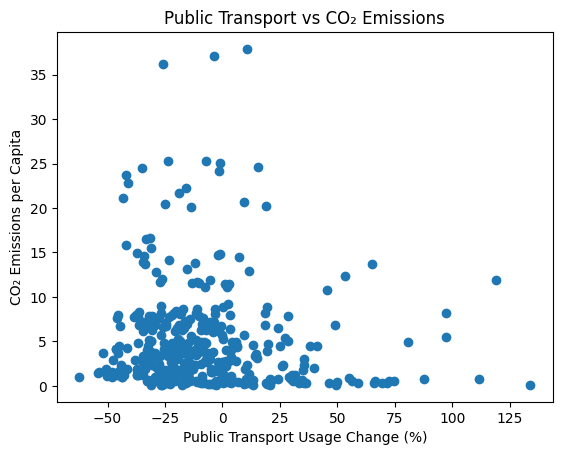

In [12]:
#11 Regression Scatter Plot
plt.scatter(
    merged_clean["transit_stations_percent_change_from_baseline"],
    merged_clean["co2_per_capita"]
)
plt.xlabel("Public Transport Usage Change (%)")
plt.ylabel("CO₂ Emissions per Capita")
plt.title("Public Transport vs CO₂ Emissions")
plt.show()


In [13]:
# ===== CO2 Impact Estimator =====
def estimate_co2_change(usage_change_percent):
    coef = model.coef_[0]
    impact = coef * usage_change_percent
    return impact

# Example scenario
test_usage = 10
impact = estimate_co2_change(test_usage)

print(f"If public transport changes by {test_usage}%,")
print(f"Estimated CO₂ change per capita: {impact:.4f}")

If public transport changes by 10%,
Estimated CO₂ change per capita: -0.1890


In [14]:
# ===== Monthly CO2 Savings Counter =====
def monthly_co2_savings(usage_change_percent, population_millions=1):
    coef = model.coef_[0]
    reduction_per_capita = coef * usage_change_percent
    total_reduction = reduction_per_capita * population_millions * 1e6
    return total_reduction

# Example
savings = monthly_co2_savings(15, population_millions=10)

print("Estimated monthly CO₂ savings (tons):", round(savings, 2))

Estimated monthly CO₂ savings (tons): -2835640.43


In [15]:
# ===== Scenario Analysis Table =====
scenario_values = [-30, -10, 0, 10, 25, 50]

scenario_df = pd.DataFrame({
    "Transport Usage Change (%)": scenario_values,
    "Predicted CO₂ Change": [estimate_co2_change(x) for x in scenario_values]
})

print("📊 Scenario Impact Analysis")
display(scenario_df)

📊 Scenario Impact Analysis


,Transport Usage Change (%),Predicted CO₂ Change
0,-30,0.567128
1,-10,0.189043
2,0,-0.000000
3,10,-0.189043
4,25,-0.472607
5,50,-0.945213


In [16]:
# ===== Future Trend Projection =====
future_usage = pd.DataFrame({
    "transit_stations_percent_change_from_baseline": [0, 10, 20, 30, 40, 50]
})
future_co2 = model.predict(future_usage)
future_projection = pd.DataFrame({
    "Usage Change (%)": future_usage.iloc[:,0],
    "Predicted CO₂ per Capita": future_co2
})

In [17]:
# ===== Simulated Live Transport Monitor =====
import time
import random
from datetime import datetime
import os

print("🚍 Simulated Live Transport Impact Monitor")

for i in range(5):
    simulated_usage = random.uniform(-20, 40)

    simulated_df = pd.DataFrame({
        "transit_stations_percent_change_from_baseline": [simulated_usage]
    })

    predicted_co2 = model.predict(simulated_df)[0]

    # ---- Save to emission log ----
    log_entry = {
        "timestamp": datetime.now(),
        "usage_change": round(simulated_usage, 2),
        "transport_mode": "Train",
        "normalized_usage": round(simulated_usage / 100, 3),
        "predicted_co2": round(predicted_co2, 3)
    }

    log_df = pd.DataFrame([log_entry])

    log_df.to_csv(
        "emission_log.csv",
        mode="a",
        header=not os.path.exists("emission_log.csv"),
        index=False
    )

    # ✅ these must be INSIDE the loop (same indent level)
    print(f"Live Usage Change: {simulated_usage:.2f}% | Predicted CO₂: {predicted_co2:.3f}")
    time.sleep(1)

🚍 Simulated Live Transport Impact Monitor
Live Usage Change: -6.58% | Predicted CO₂: 5.090
Live Usage Change: 15.39% | Predicted CO₂: 4.675
Live Usage Change: -0.14% | Predicted CO₂: 4.969
Live Usage Change: -5.42% | Predicted CO₂: 5.069
Live Usage Change: 20.38% | Predicted CO₂: 4.581


In [18]:
# ===== Save Results to CSV =====
output_path = "eco_transit_results.csv"

future_projection.to_csv(output_path, index=False)

print("✅ Results saved to:", output_path)

✅ Results saved to: eco_transit_results.csv


##  Interpretation of Results

The regression coefficient indicates how CO₂ emissions per capita change
with variations in public transport usage. A negative coefficient suggests
that increased public transport usage is associated with reduced CO₂ emissions.

Specifically, a 1% increase in public transport usage is linked to an average
decrease of approximately 0.019 metric tons of CO₂ per capita.

The intercept represents the estimated CO₂ emissions when there is no change
in public transport usage. These results indicate an association and do not
imply direct causation, as other factors also influence emissions.



### Model Limitations and Assumptions

This analysis uses a simple linear regression model to study the relationship between public transport usage and CO₂ emissions per capita. While the results indicate a negative association, the model has several limitations.

First, the regression considers only one independent variable (public transport usage), whereas CO₂ emissions are influenced by multiple factors such as industrial activity, population growth, energy sources, economic development, and government policies.

Second, the data is aggregated at the country level, which may hide regional or city-level variations in transport usage and emissions.

Third, the analysis shows correlation, not causation. A negative coefficient does not guarantee that increased public transport usage alone directly causes a reduction in CO₂ emissions.

Despite these limitations, the model provides useful insights into the potential role of public transport in supporting environmental sustainability.


### Future Scope

Future work can improve this study by including additional variables such as private vehicle usage, fuel consumption, renewable energy adoption, population density, and economic indicators.

Using city-level or regional datasets could provide more detailed insights into urban mobility patterns. Advanced models such as multiple linear regression, time-series analysis, or machine learning techniques can also be applied to better capture complex relationships between transport usage and emissions.

Additionally, incorporating policy changes and infrastructure developments would help in evaluating the long-term impact of public transport on environmental sustainability.

In [19]:
# ===== Model Validation =====
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = merged_clean[["transit_stations_percent_change_from_baseline"]]
y = merged_clean["co2_per_capita"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_eval = LinearRegression()
model_eval.fit(X_train, y_train)

y_pred_eval = model_eval.predict(X_test)

print("📊 Model Evaluation")
print("R² Score:", r2_score(y_test, y_pred_eval))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_eval)))

📊 Model Evaluation
R² Score: 0.00831755614798646
RMSE: 6.406436334056675


##  Conclusion

This study analyzed the relationship between public transport usage and CO₂ emissions per capita using real-world datasets.The results show a weak but negative relationship, indicating that increased public transport usage is associated with stable or slightly reduced CO₂ emissions. The linear regression analysis supports this observation by showing a small decrease in emissions with increased public transport usage. Although the results indicate correlation rather than causation, they highlight the importance of public transportation in supporting sustainable urban mobility. Promoting public transport, along with other environmental measures, can contribute to long-term emission reduction and sustainable development.